In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ReadParquet") \
    .getOrCreate()

df = spark.read.parquet("/content/drive/MyDrive/534_data_new/floor_1st Floor/")

df.show()

+---------+---------+-----------------+------------------+--------------------+--------------------+
|     Site|    Level|    ClientMacAddr|               lat|                 lng|           localtime|
+---------+---------+-----------------+------------------+--------------------+--------------------+
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460445049903555|-0.93304832250945491|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460787714833408|-0.93228751629167728|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460445049903555|-0.93304832250945491|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.93229241478818181|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.93229241478818181|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460447921188994|-0.93304769620569283|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.93229241478818181|2020-09-01 2

In [ ]:
from pyspark.sql.functions import col, to_timestamp, regexp_replace

spark.conf.set("spark.sql.legacy.timeParserPolicy", "CORRECTED")

df = df.withColumn(
    "localtime",
    to_timestamp(regexp_replace(col("localtime"), " UTC", ""), "yyyy-MM-dd HH:mm:ss[.SSS]")
)

df = df.withColumn("lat", df["lat"].cast("double")) \
       .withColumn("lng", df["lng"].cast("double"))

df.show()

+---------+---------+-----------------+------------------+-------------------+--------------------+
|     Site|    Level|    ClientMacAddr|               lat|                lng|           localtime|
+---------+---------+-----------------+------------------+-------------------+--------------------+
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460445049903555|-0.9330483225094549|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c| 51.46078771483341|-0.9322875162916773|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460445049903555|-0.9330483225094549|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.9322924147881818|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.9322924147881818|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:1c:5e|51.460447921188994|-0.9330476962056928|2020-09-01 23:58:...|
|UK Office|1st Floor|9c:8c:6e:46:0b:7c|51.460782270154844|-0.9322924147881818|2020-09-01 23:58:...|


In [ ]:
from pyspark.sql import functions as F
mac_count = df.groupBy("ClientMacAddr").count()
mac_count.orderBy(F.col("count").asc()).show(20, truncate=False)

+-----------------+-----+
|ClientMacAddr    |count|
+-----------------+-----+
|88:b4:a6:7d:8a:cc|1    |
|58:d9:c3:4f:50:f7|1    |
|88:b4:a6:dc:31:75|1    |
|80:58:f8:6b:8b:74|1    |
|80:58:f8:50:15:a3|1    |
|84:cf:bf:8a:54:29|1    |
|38:80:df:c6:ba:00|1    |
|88:b4:a6:bb:36:e6|1    |
|f0:79:60:8a:3a:01|1    |
|80:58:f8:2d:29:25|1    |
|dc:56:e7:89:11:0d|1    |
|f4:f5:24:7e:32:ad|1    |
|88:b4:a6:3a:5a:56|1    |
|d0:77:14:b8:4a:af|1    |
|80:58:f8:eb:b0:75|1    |
|80:58:f8:75:b9:10|1    |
|80:58:f8:4c:33:d2|1    |
|80:58:f8:00:c5:53|1    |
|80:58:f8:c8:45:9c|1    |
|80:58:f8:44:2d:f2|1    |
+-----------------+-----+
only showing top 20 rows



In [ ]:
mac_count = df.groupBy("ClientMacAddr").count()

ten_counts = mac_count.filter(F.col("count") <= 10)

df = df.join(ten_counts, on="ClientMacAddr", how="left_anti")

df.show()
print(df.count())

+-----------------+---------+---------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|    Level|               lat|                lng|           localtime|
+-----------------+---------+---------+------------------+-------------------+--------------------+
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46040043720453|-0.9326676520490081|2020-08-24 10:56:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:56:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|


In [ ]:
mac_counts = df.groupBy("ClientMacAddr").agg(
    F.countDistinct("lat").alias("lat_count"),
    F.countDistinct("lng").alias("lng_count")
)

mac_with_unique_location = mac_counts.filter(
    (F.col("lat_count") == 1) & (F.col("lng_count") == 1)
).select("ClientMacAddr")

unique_mac = df.join(mac_with_unique_location, on="ClientMacAddr", how="inner")

unique_mac.show()
print(unique_mac.count())

+-----------------+---------+---------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|    Level|               lat|                lng|           localtime|
+-----------------+---------+---------+------------------+-------------------+--------------------+
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:14:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:14:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:14:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:14:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:14:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:13:...|
|00:0c:e7:d8:f1:ba|UK Office|1st Floor| 51.46079197085533|-0.9323567990154695|2020-08-24 10:13:...|


In [ ]:
unique_mac_count = unique_mac.select("ClientMacAddr").distinct().count()

print(unique_mac_count)

7171


In [ ]:
df_remaining = df.join(mac_with_unique_location, on="ClientMacAddr", how="left_anti")

df_remaining.show()
print(df_remaining.count())

+-----------------+---------+---------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|    Level|               lat|                lng|           localtime|
+-----------------+---------+---------+------------------+-------------------+--------------------+
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46040043720453|-0.9326676520490081|2020-08-24 10:56:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:56:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|
|00:0c:e7:69:b8:1f|UK Office|1st Floor| 51.46042396363068| -0.932516895372709|2020-08-24 10:55:...|


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import math
from pyspark.sql.types import DoubleType
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = math.sin(delta_phi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return round(R * c * 1000, 3)

haversine_udf = F.udf(haversine, DoubleType())

In [ ]:
windowSpec = Window.partitionBy("ClientMacAddr").orderBy("localtime")

df_remaining = df_remaining.withColumn("prev_lat", F.lag("lat").over(windowSpec)) \
       .withColumn("prev_lng", F.lag("lng").over(windowSpec)) \
       .withColumn("prev_localtime", F.lag("localtime").over(windowSpec))

In [ ]:
df_remaining = df_remaining.na.drop()

In [ ]:
df_remaining.show()

+-----------------+---------+---------+------------------+-------------------+--------------------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|    Level|               lat|                lng|           localtime|          prev_lat|           prev_lng|      prev_localtime|
+-----------------+---------+---------+------------------+-------------------+--------------------+------------------+-------------------+--------------------+
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 

In [ ]:
df_remaining = df_remaining.withColumn("distance", haversine_udf("lat", "lng", "prev_lat", "prev_lng"))
df_remaining.select("distance").show()

+--------+
|distance|
+--------+
|   2.051|
|   2.933|
|  10.053|
|   3.431|
|   6.985|
|   7.298|
|   8.809|
|   5.293|
|  12.321|
|   9.723|
|   9.444|
|   9.327|
|  11.585|
|   2.576|
|   8.814|
|  10.823|
|   1.164|
|   0.577|
|  11.954|
|  12.442|
+--------+
only showing top 20 rows



In [ ]:
df_remaining = df_remaining.withColumn("distance", haversine_udf("lat", "lng", "prev_lat", "prev_lng"))

df_remaining = df_remaining.withColumn("time_diff", (F.unix_timestamp("localtime") - F.unix_timestamp("prev_localtime")))

df_remaining = df_remaining.withColumn("speed", F.when(F.col("time_diff") > 0, F.col("distance") / F.col("time_diff")).otherwise(0))

df_remaining.select("ClientMacAddr", "localtime", "lat", "lng", "distance", "time_diff", "speed").show()

+-----------------+--------------------+------------------+-------------------+--------+---------+--------------------+
|    ClientMacAddr|           localtime|               lat|                lng|distance|time_diff|               speed|
+-----------------+--------------------+------------------+-------------------+--------+---------+--------------------+
|00:08:22:c6:bb:fb|2020-06-22 07:41:...|  51.4603668575462|-0.9325434689255484|   2.307|     1415|0.001630388692579...|
|00:08:22:c6:bb:fb|2020-06-22 07:41:...|51.460371825543035|-0.9325498840710928|   0.709|       16|           0.0443125|
|00:08:22:c6:bb:fb|2020-06-22 07:41:...| 51.46037144186724|-0.9325331146346303|   1.163|        6| 0.19383333333333333|
|00:08:22:c6:bb:fb|2020-06-22 07:41:...| 51.46037079289548|-0.9325340243643263|   0.096|       12|               0.008|
|00:08:22:c6:bb:fb|2020-06-22 07:41:...| 51.46037079289548|-0.9325340243643263|     0.0|       13|                 0.0|
|00:08:22:c6:bb:fb|2020-06-22 07:41:...|

In [ ]:
from pyspark.sql.functions import col

df_remaining.select("speed").orderBy(col("speed").desc()).show()

+------+
| speed|
+------+
|66.854|
|61.712|
|61.349|
| 60.18|
|59.944|
|59.944|
|59.944|
|59.944|
|59.944|
|59.944|
|58.029|
|57.277|
|56.867|
| 56.69|
|56.583|
|55.073|
|54.993|
| 53.78|
|53.417|
|53.273|
+------+
only showing top 20 rows



In [ ]:
from pyspark.sql.functions import col

count = df_remaining.filter(col("speed") < 2).select("ClientMacAddr").distinct().count()
print("speed < 2 的不同 macaddress 数量为：", count)

speed < 2 的不同 macaddress 数量为： 4114


In [ ]:
df_filtered = df_remaining.filter(col("speed") > 2).select("ClientMacAddr", "lat", "lng")

pdf = df_filtered.toPandas()
pdf

,ClientMacAddr,lat,lng
0,00:0c:e7:25:3e:3d,51.460479,-0.932562
1,00:0c:e7:28:a1:b4,51.460428,-0.932444
2,00:0c:e7:5f:45:c3,51.460950,-0.932186
3,00:0c:e7:af:8c:76,51.460666,-0.932334
4,00:0c:e7:cf:4f:28,51.460528,-0.932429
...,...,...,...
640357,fc:fc:48:36:16:6b,51.460620,-0.932407
640358,fc:fc:48:36:16:6b,51.460802,-0.932216
640359,fc:fc:48:36:16:6b,51.460802,-0.932216
640360,fc:fc:48:36:16:6b,51.460802,-0.932216


In [ ]:
import pandas as pd
pdf_1 = unique_mac.select("ClientMacAddr", "lat", "lng").toPandas()
df_merged = pd.concat([pdf, pdf_1], ignore_index=True)
df_merged

,ClientMacAddr,lat,lng
0,00:0c:e7:25:3e:3d,51.460479,-0.932562
1,00:0c:e7:28:a1:b4,51.460428,-0.932444
2,00:0c:e7:5f:45:c3,51.460950,-0.932186
3,00:0c:e7:af:8c:76,51.460666,-0.932334
4,00:0c:e7:cf:4f:28,51.460528,-0.932429
...,...,...,...
737188,88:b4:a6:8c:c9:f2,51.460775,-0.932322
737189,88:b4:a6:8c:c9:f2,51.460775,-0.932322
737190,88:b4:a6:8c:c9:f2,51.460775,-0.932322
737191,88:b4:a6:8c:c9:f2,51.460775,-0.932322


In [ ]:
fixed_mac_mode_coords = df_merged.groupby('ClientMacAddr')[['ClientMacAddr', 'lat', 'lng']].apply(lambda x: x.mode().iloc[0])
print(fixed_mac_mode_coords)

0                      ClientMacAddr        lat       lng
ClientMacAddr                                            
00:08:22:1a:c2:fb  00:08:22:1a:c2:fb  51.460898 -0.932198
00:08:22:2a:c1:fb  00:08:22:2a:c1:fb  51.460805 -0.932186
00:08:22:2e:17:fc  00:08:22:2e:17:fc  51.460402 -0.933070
00:08:22:40:d8:fb  00:08:22:40:d8:fb  51.460472 -0.932239
00:08:22:4c:c2:fb  00:08:22:4c:c2:fb  51.460420 -0.932617
...                              ...        ...       ...
fc:a6:67:be:c0:a5  fc:a6:67:be:c0:a5  51.460950 -0.932186
fc:b6:d8:b2:7a:56  fc:b6:d8:b2:7a:56  51.460405 -0.933019
fc:d8:48:80:ab:de  fc:d8:48:80:ab:de  51.460358 -0.932705
fc:db:b3:31:4e:a8  fc:db:b3:31:4e:a8  51.460411 -0.933036
fc:fc:48:36:16:6b  fc:fc:48:36:16:6b  51.460802 -0.932216

[11187 rows x 3 columns]


In [ ]:
fixed_mac_mode_coords.columns

Index(['ClientMacAddr', 'lat', 'lng'], dtype='object', name=0)

In [ ]:
import pandas as pd
import numpy as np

selected_macs = fixed_mac_mode_coords.sample(n=50, random_state=42).reset_index(drop=True)

time_range = pd.date_range(start="2019-09-01 00:00:00", end="2019-09-01 23:55:00", freq="10min")

device_time_grid = selected_macs.merge(
    pd.DataFrame({'localtime': time_range}),
    how='cross'
)

np.random.seed(42)

def simulate_temp():
    prob = np.random.rand()
    if prob < 0.98:
        return np.random.normal(25, 2)
    elif prob < 0.988:
        return np.random.normal(32, 1)
    else:
        return np.random.normal(38, 1.5)

def simulate_pressure():
    prob = np.random.rand()
    if prob < 0.93:
        return np.random.normal(1.5, 0.2)
    elif prob < 0.995:
        return np.random.normal(2.1, 0.1)
    else:
        return np.random.normal(2.7, 0.2)

device_time_grid["temperature"] = [simulate_temp() for _ in range(len(device_time_grid))]
device_time_grid["pressure"] = [simulate_pressure() for _ in range(len(device_time_grid))]

def classify_leak(temp, pressure):
    if temp > 35 or pressure > 2.5:
        return "Severe Leakage"
    elif temp > 30 or pressure > 2.0:
        return "Potential Leakage"
    else:
        return "Normal"

device_time_grid["leak_level"] = device_time_grid.apply(
    lambda row: classify_leak(row["temperature"], row["pressure"]),
    axis=1
)

df_simulated = device_time_grid.rename(columns={
    "lat": "latitude",
    "lng": "longitude"
})[["ClientMacAddr", "latitude", "longitude", "localtime", "temperature", "pressure", "leak_level"]]

df_simulated.head()

,ClientMacAddr,latitude,longitude,localtime,temperature,pressure,leak_level
0,38:80:df:40:13:f4,51.46035,-0.932498,2019-09-01 00:00:00,22.776240,1.192784,正常
1,38:80:df:40:13:f4,51.46035,-0.932498,2019-09-01 00:10:00,25.637804,1.186806,正常
2,38:80:df:40:13:f4,51.46035,-0.932498,2019-09-01 00:20:00,25.558083,1.382760,正常
3,38:80:df:40:13:f4,51.46035,-0.932498,2019-09-01 00:30:00,27.021031,2.127750,可能泄漏
4,38:80:df:40:13:f4,51.46035,-0.932498,2019-09-01 00:40:00,23.838244,1.723050,正常


In [ ]:
import plotly.express as px

df_simulated["localtime"] = pd.to_datetime(df_simulated["localtime"])
df_simulated["localtime_str"] = df_simulated["localtime"].dt.strftime("%H:%M")

level_color = {
    "Normal": "green",
    "Potential Leakage": "orange",
    "Severe Leakage": "red"
}


center_lat = df_simulated["latitude"].mean()
center_lon = df_simulated["longitude"].mean()


lat_range = df_simulated["latitude"].max() - df_simulated["latitude"].min()
lon_range = df_simulated["longitude"].max() - df_simulated["longitude"].min()
buffer = 0.01

fig = px.scatter_mapbox(
    df_simulated,
    lat="latitude",
    lon="longitude",
    color="leak_level",
    color_discrete_map=level_color,
    animation_frame="localtime_str",
    hover_name="ClientMacAddr",
    zoom=11,
    height=700,
    title="Real-Time Leakage Map for 50 Devices"
)

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=11,
    mapbox_bounds={
        "west": df_simulated["longitude"].min() - buffer,
        "east": df_simulated["longitude"].max() + buffer,
        "south": df_simulated["latitude"].min() - buffer,
        "north": df_simulated["latitude"].max() + buffer
    },
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

In [ ]:
fig.write_html("leak_map_animated.html")
from google.colab import files
files.download("leak_map_animated.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

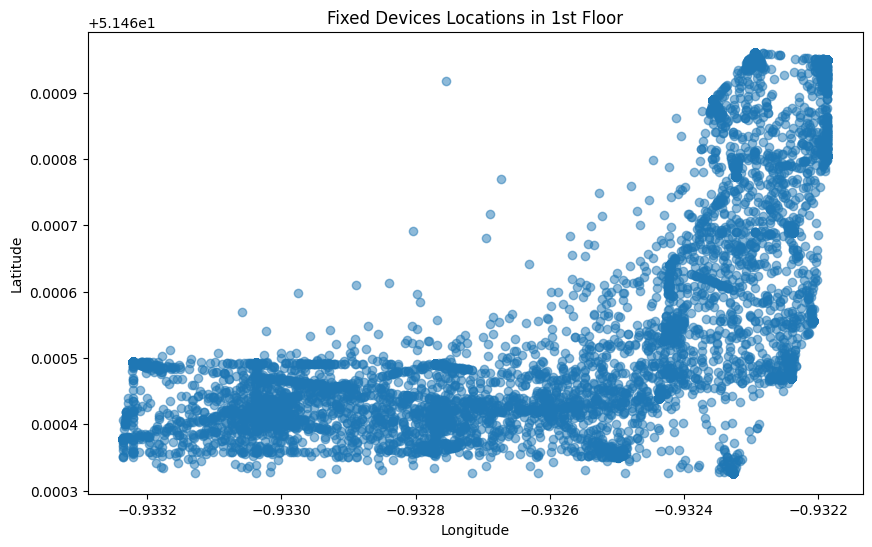

In [ ]:
#Ditribution of fixed devices in 3rd floor
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(fixed_mac_mode_coords['lng'], fixed_mac_mode_coords['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations in 1st Floor')
plt.show()